
# 🔋 Analisi dell’aumento dei prezzi del carburante e correlazione con la crescita delle auto elettriche  

**Gabriele Cavan**  
Matricola: 172003

## 📊 Obiettivo dell’analisi

Studiare la relazione tra:
- aumento dei prezzi dei carburanti fossili  
- crescita degli acquisti di veicoli elettrici (EV)

---

## ❓ Domande chiave

- L’aumento del costo dei carburanti spinge davvero l’acquisto di EV?  
- Esiste una **correlazione** tra prezzi carburanti e vendite EV?  
- Gli effetti sono immediati o ci sono **ritardi nel tempo**?

## ⚡ Fattori aggiuntivi

- Miglioramento efficienza EV  
  ➤ meno costi / più km  
- Possibili cali nelle vendite durante crisi energetiche

---

## 💰 Confronto economico

- Analisi del **costo per km ($/km)**:
  - EV vs benzina/diesel/GPL  

---

## 🎯 Obiettivo finale

Capire se esiste una relazione concreta tra:
- aumento prezzi carburanti  
- diffusione dei veicoli elettrici  
e quali fattori la influenzano.

## 📚 Risorse Utilizzate

Per questa analisi sono stati utilizzati diversi dataset, focalizzati su aspetti economici e tecnici:

---

### ⛽ Prezzi carburanti
- Prezzi globali dei carburanti  

---

### 🚗 Adozione veicoli elettrici
- Dati sul trend di acquisto degli EV nel tempo  
➤ Misura la crescita della diffusione

### ⚙️ Efficienza veicoli
- Veicoli elettrici (EV): km per kWh  
- Veicoli a combustione (ICE): km per litro  
➤ Permette il confronto delle prestazioni

---

### 💰 Costo per utilizzo 
- Calcolo del costo medio per km ($/km)  
➤ Confronto diretto tra EV e ICE

---

## 🎯 Obiettivo

Integrare questi dati per analizzare possibili correlazioni tra:
- aumento prezzi carburanti  
- diffusione veicoli elettrici


## 📚 Dataset

I dataset utilizzati sono stati creati in periodi diversi, tutti però comprendevano il periodo 2020-2024 su cui è stata effettuata l'analisi dati. Inoltre tutti i dataset sono stati aggiornati nelle settimane precedenti alla realizzazione del progettino.

---

### ⛽ Prezzi carburanti
- fuel_prices_region_africa.csv
- fuel_prices_region_asia.csv
- fuel_prices_region_europe.csv
- fuel_prices_region_latin_america.csv
- fuel_prices_region_middle_east.csv
- fuel_prices_region_north_america.csv

---

### 🚗 Adozione veicoli elettrici
- ev_adoption_trends.csv

### ⚙️ Efficienza veicoli
- cars_fuel_efficiency.csv
- ev_energy_efficiency_dataset.csv

---

### 💰 Costo per utilizzo 
- ev_adoption_trends.csv
- cars_fuel_efficiency.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import itables
from itables import show

itables.init_notebook_mode()
itables.options.warn_on_undocumented_option=False
itables.options.maxBytes = "4MB"

COLOR = {'benzina': '#E85D24', 'diesel': '#C0392B', 'elettrico': '#1D9E75'}
FIG_W, FIG_H = 13, 5

In [3]:
# Leggi CSV
df_africa = pd.read_csv('data/fuel_prices_region_africa.csv')
df_asia = pd.read_csv('data/fuel_prices_region_asia.csv')
df_europe = pd.read_csv('data/fuel_prices_region_europe.csv')
df_latin_america = pd.read_csv('data/fuel_prices_region_latin_america.csv')
df_middle_east = pd.read_csv('data/fuel_prices_region_middle_east.csv')
df_north_america = pd.read_csv('data/fuel_prices_region_north_america.csv')

df = pd.concat([df_europe, df_africa, df_asia, df_latin_america, df_middle_east, df_north_america])

df_filtrato = df[(df["year"] >= 2020)]

df_filtrato.drop(columns=['iso3',
                          'gasoline_usd_per_gallon',
                          'gasoline_real_2024usd',
                          'diesel_real_2024usd',
                          'gasoline_local_currency',
                          'tax_pct_of_pump_price',
                          'pretax_price_usd_ltr',
                          'subsidy_flag',
                          'subsidy_regime',
                          'is_oil_producer',
                          'crude_oil_usd_per_barrel',
                          'crude_oil_usd_per_liter',
                          'refinery_margin_usd_ltr',
                          'oil_price_shock_idx',
                          'us_cpi'
                         ], inplace=True)

df_filtrato.rename(columns={'gasoline_yoy_pct_change': 'gasoline_percentage_price_change_year_per_year'}, inplace=True)

# Mostra tabella interattiva
# show(df_filtrato, pageLength=10, scrollX=True)

In [4]:
df_ev_adoption_trend = pd.read_csv("data/ev_adoption_trends.csv")

df_ev_adoption_trend.drop(columns=['record_id',
                                   'area_type',
                                   'buyer_type',
                                   'vehicle_segment',
                                   'government_incentive_type',
                                   'incentive_amount_usd',
                                   'primary_charging_type',
                                   'resale_value_pct_3yr',
                                   'adas_level',
                                   'customer_gender',
                                   'customer_age_group',
                                   'customer_satisfaction',
                                   'would_recommend',
                                   'month',
                                   'quarter',
                                   'ev_model',
                                   'ev_type',
                                   'effective_price_usd',
                                   'charging_time_hours',
                                   'charging_station_access'
                                  ], inplace=True)

df_ev_adoption_trend.groupby('ev_brand')[['price_usd',
                                          'range_km',
                                          'battery_capacity_kwh',
                                          'annual_mileage_km',
                                          'electricity_cost_per_km_usd',
                                          'co2_savings_kg_per_year'
                                          ]].mean()

# show(df_ev_adoption_trend, pagelength = 10, scrollX=True)

Loading ITables v2.8.0 from the init_notebook_mode cell... (need help?)


In [5]:
df_fuel_efficiency = pd.read_csv('data/cars_fuel_efficiency_clean.csv')

df_fuel_efficiency.drop(columns=['trip_id',
                                 'vehicle_type',
                                 'trip_category',
                                 'efficiency_band',
                                 'avg_speed_kmph',
                                 'base_mileage_kmpl',
                                 'mileage_delta_kmpl',
                                 'fuel_cost_usd',
                                 'trip_duration_hr',
                                 'distance_km'
                                ], inplace=True)

df_grouped = df_fuel_efficiency.groupby(
    ['car_name', 'fuel_type'],
    observed=True
)[
    ['actual_mileage_kmpl',
     'fuel_consumed_L',
     'cost_per_km_usd',
     'co2_emissions_kg',
     'co2_per_km',
     'relative_efficiency']
].mean().unstack()



# show(df_grouped, pagelength=10, scrollX=True)
# fare confronto tra benzina/petrolio/elettrico
# kmpl = kilometri per litro

In [6]:
df_EVeff = pd.read_csv('data/EV Energy Efficiency Dataset.csv')

df_EVeff.drop(columns=['Vehicle class',
                       'Motor (kW)',
                       'Recharge time (h)',
                      ], inplace=True)

df_EVeff_filter = df_EVeff[(df_EVeff['Model year'] >= 2020) & (df_EVeff['Model year'] <= 2024)]

# show(df_EVeff_filter, pagelength = 10, scrollX=True)

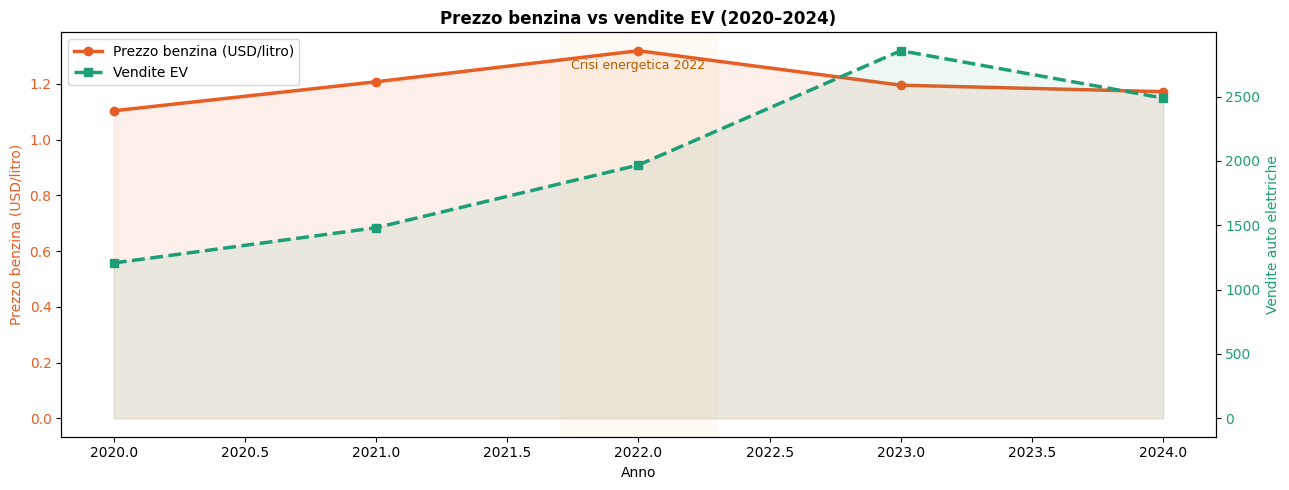

In [7]:
# Prezzo medio benzina globale per anno
gasoil_col = [c for c in df_filtrato.columns if 'gasoline_usd' in c and 'gallon' not in c][0]
fuel_global = df_filtrato.groupby('year')[gasoil_col].mean().reset_index(name='prezzo_medio_benzina')

ev_by_year = df_ev_adoption_trend.groupby('year').size().reset_index(name='vendite_ev')
merged = pd.merge(fuel_global, ev_by_year, on='year', how='inner')

fig, ax1 = plt.subplots(figsize=(FIG_W, FIG_H))
ax2 = ax1.twinx()

l1, = ax1.plot(merged['year'], merged['prezzo_medio_benzina'],
               color=COLOR['benzina'], lw=2.5, marker='o', label='Prezzo benzina (USD/litro)')
l2, = ax2.plot(merged['year'], merged['vendite_ev'],
               color=COLOR['elettrico'], lw=2.5, marker='s', linestyle='--', label='Vendite EV')

ax1.fill_between(merged['year'], merged['prezzo_medio_benzina'], alpha=0.1, color=COLOR['benzina'])
ax2.fill_between(merged['year'], merged['vendite_ev'], alpha=0.08, color=COLOR['elettrico'])

ax1.axvspan(2021.7, 2022.3, alpha=0.08, color='#FFD27F')
ax1.text(2022, merged['prezzo_medio_benzina'].max() * 0.95,
         'Crisi energetica 2022', fontsize=9, ha='center', color='#B55B00')

ax1.set_xlabel('Anno')
ax1.set_ylabel('Prezzo benzina (USD/litro)', color=COLOR['benzina'])
ax2.set_ylabel('Vendite auto elettriche', color=COLOR['elettrico'])
ax1.tick_params(axis='y', labelcolor=COLOR['benzina'])
ax2.tick_params(axis='y', labelcolor=COLOR['elettrico'])

ax1.set_title('Prezzo benzina vs vendite EV (2020–2024)', fontweight='bold')
ax1.legend([l1, l2], [l1.get_label(), l2.get_label()], loc='upper left')

plt.tight_layout()
plt.savefig('figures/03_dual_axis_fuel_vs_ev.png', dpi=150, bbox_inches='tight')
plt.show()


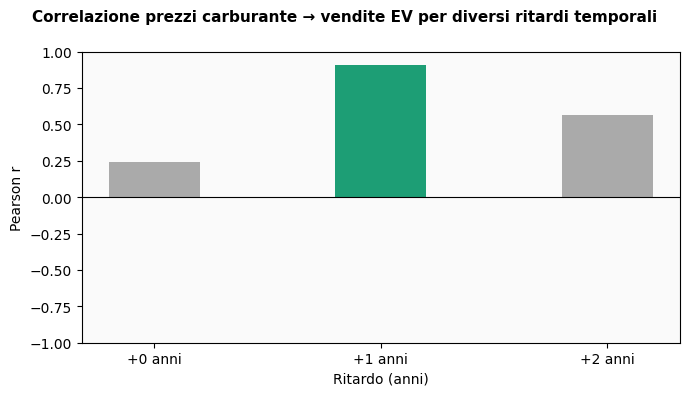

 lag (anni)  Pearson r  p-value
          0      0.240   0.6975
          1      0.907   0.0933
          2      0.567   0.6166

→ Il lag con correlazione più forte è: 1 anno/i


In [8]:
# Analisi del lag
from scipy.stats import pearsonr, spearmanr, linregress

max_lag = min(3, len(merged) - 1)
lag_results = []

for lag in range(0, max_lag + 1):
    fuel_shifted = merged['prezzo_medio_benzina'].values[:len(merged) - lag]
    ev_future = merged['vendite_ev'].values[lag:]
    if len(fuel_shifted) >= 3:
        r, p = pearsonr(fuel_shifted, ev_future)
        lag_results.append({'lag (anni)': lag, 'Pearson r': round(r, 3), 'p-value': round(p, 4)})

df_lag = pd.DataFrame(lag_results)

fig, ax = plt.subplots(figsize=(7, 4))
colors_lag = [COLOR['elettrico'] if r == df_lag['Pearson r'].abs().max() else '#aaa' for r in df_lag['Pearson r'].abs()]
ax.bar(df_lag['lag (anni)'].astype(str).apply(lambda x: f'+{x} anni'), df_lag['Pearson r'],
       color=colors_lag, width=0.4)
ax.axhline(0, color='black', lw=0.8)
plt.suptitle('Correlazione prezzi carburante → vendite EV per diversi ritardi temporali',
             fontsize=11, fontweight='bold')
ax.set_ylabel('Pearson r')
ax.set_xlabel('Ritardo (anni)')
ax.set_ylim(-1, 1)
ax.set_facecolor('#fafafa')
plt.tight_layout()
plt.savefig('figures/07_lag_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(df_lag.to_string(index=False))
best_lag = df_lag.loc[df_lag['Pearson r'].abs().idxmax(), 'lag (anni)']
print(f'\n→ Il lag con correlazione più forte è: {best_lag} anno/i')


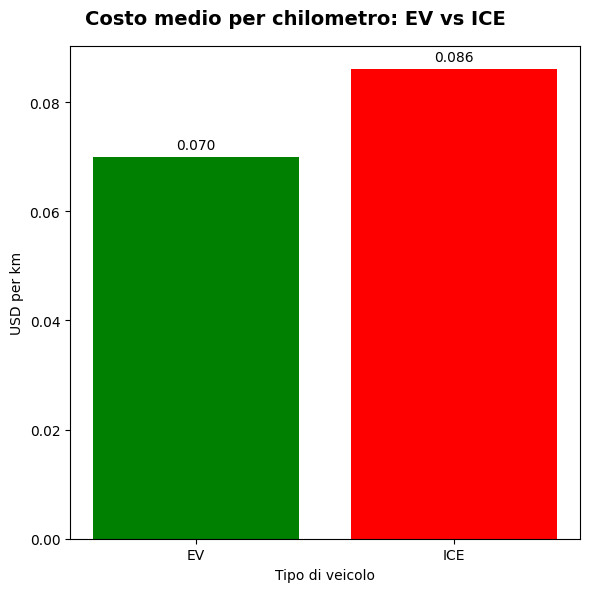

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# EV: uso costo elettrico per km dal dataset adozione
ev = pd.read_csv('data/ev_adoption_trends.csv')
ev = ev[ev['year'] >= 2020]
mean_ev_cost = ev['electricity_cost_per_km_usd'].mean()

# ICE: uso dataset di efficienza auto per costo per km
cars = pd.read_csv('data/cars_fuel_efficiency_clean.csv')
cars['fuel_type_clean'] = cars['fuel_type'].str.lower()
mean_ice_cost = cars[cars['fuel_type_clean'].str.contains('petrol|gasoline|diesel', na=False)]['cost_per_km_usd'].mean()

labels = ['EV', 'ICE']
values = [mean_ev_cost, mean_ice_cost]

fig.suptitle('Trend dei prezzi della benzina e delle immatricolazioni EV (2020-2024)', fontsize=14, fontweight='bold')
fig.text(0.5, -0.02, 'Confronto tra prezzo medio benzina e numero di veicoli EV. La correlazione non indica causalità.', ha='center', fontsize=10)

plt.figure(figsize=(6, 6))
plt.suptitle('Costo medio per chilometro: EV vs ICE', fontsize=14, fontweight='bold')

bars = plt.bar(labels, values, color=['green', 'red'])
plt.xlabel('Tipo di veicolo')
plt.ylabel('USD per km')
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.001, f"{value:.3f}", ha='center', va='bottom')
plt.tight_layout()

Media ICE (km/kWh): 1.64
2020: EV mean = 7.28
2021: EV mean = 7.26
2022: EV mean = 7.00
2023: EV mean = 7.16
2024: EV mean = 6.92


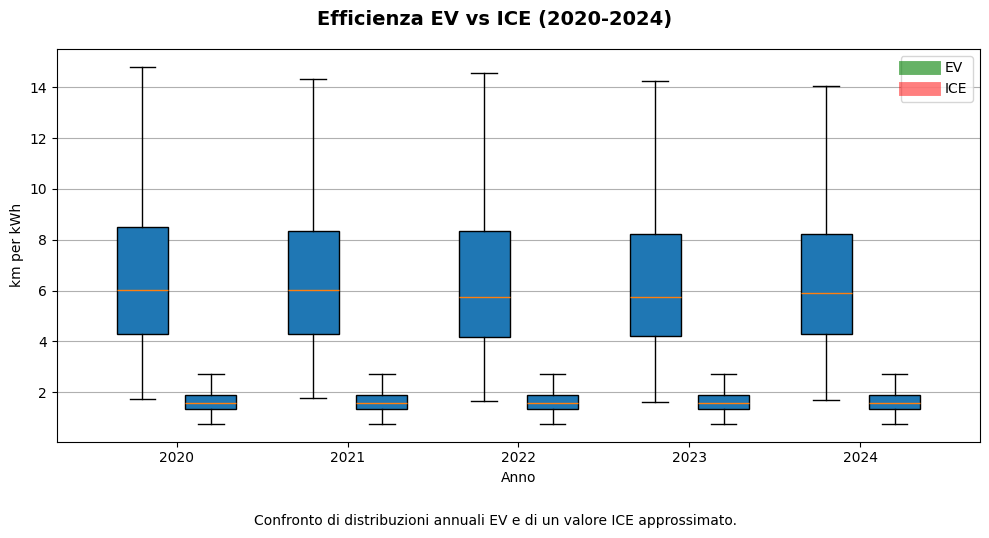

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Prepara dati EV
ev = pd.read_csv('data/ev_adoption_trends.csv')
ev = ev[(ev['battery_capacity_kwh'] > 0) & (ev['range_km'] > 0) & (ev['year'] >= 2020)]
ev['ev_km_per_kwh'] = ev['range_km'] / ev['battery_capacity_kwh']

years = sorted(ev['year'].unique())
ev_groups = [ev[ev['year'] == year]['ev_km_per_kwh'].values for year in years]

# ICE dati
df_ice = pd.read_csv('data/cars_fuel_efficiency_clean.csv')
df_ice = df_ice[df_ice['actual_mileage_kmpl'] > 0]
df_ice['ice_km_per_kwh'] = df_ice['actual_mileage_kmpl'] / 9.7
ice_vals = df_ice['ice_km_per_kwh'].values

plt.figure(figsize=(10, 5))
plt.boxplot(ev_groups, positions=[year - 0.2 for year in years], widths=0.3, patch_artist=True, tick_labels=years, showfliers=False)
plt.boxplot([ice_vals] * len(years), positions=[year + 0.2 for year in years], widths=0.3, patch_artist=True, showfliers=False)

plt.suptitle('Efficienza EV vs ICE (2020-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Anno')
plt.ylabel('km per kWh')
plt.xticks(years)
plt.grid(True, axis='y')
plt.legend([plt.Line2D([0], [0], color='green', lw=10, alpha=0.6), plt.Line2D([0], [0], color='red', lw=10, alpha=0.5)], ['EV', 'ICE'], loc='upper right')
plt.figtext(0.5, -0.05, 'Confronto di distribuzioni annuali EV e di un valore ICE approssimato.', ha='center', fontsize=10)
plt.tight_layout()

mean_ice = ice_vals.mean()
print(f'Media ICE (km/kWh): {mean_ice:.2f}')
for year, values in zip(years, ev_groups):
    print(f'{year}: EV mean = {np.mean(values):.2f}')

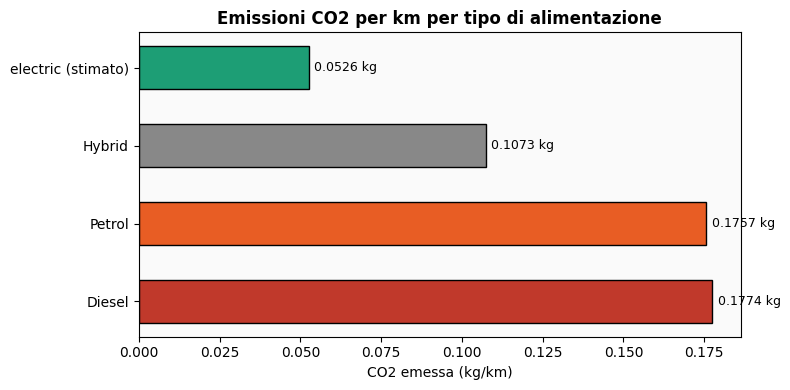

In [11]:
if 'fuel_type' in df_fuel_efficiency.columns and 'co2_per_km' in df_fuel_efficiency.columns:
    co2_by_fuel = df_fuel_efficiency.groupby('fuel_type')['co2_per_km'].mean().reset_index()

    if 'co2_savings_kg_per_year' in df_ev_adoption_trend.columns and 'annual_mileage_km' in df_ev_adoption_trend.columns:
        ev_annual_km = df_ev_adoption_trend['annual_mileage_km'].mean()
        ev_co2_savings = df_ev_adoption_trend['co2_savings_kg_per_year'].mean()
        co2_fossil_avg = co2_by_fuel['co2_per_km'].mean()
        ev_co2_per_km = max(0, co2_fossil_avg - (ev_co2_savings / ev_annual_km))
        ev_co2_row = pd.DataFrame({'fuel_type': ['electric (stimato)'], 'co2_per_km': [ev_co2_per_km]})
        co2_by_fuel = pd.concat([co2_by_fuel, ev_co2_row], ignore_index=True)

    co2_by_fuel = co2_by_fuel.sort_values('co2_per_km', ascending=False)
    color_map = {'gasoline': COLOR['benzina'], 'petrol': COLOR['benzina'], 'diesel': COLOR['diesel'],
                 'electric': COLOR['elettrico'], 'electric (stimato)': COLOR['elettrico']}
    colors = [color_map.get(ft.lower(), '#888') for ft in co2_by_fuel['fuel_type']]

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(co2_by_fuel['fuel_type'], co2_by_fuel['co2_per_km'],
                   color=colors, height=0.55, edgecolor='black')
    for bar, val in zip(bars, co2_by_fuel['co2_per_km']):
        ax.text(val + co2_by_fuel['co2_per_km'].max()*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{val:.4f} kg', va='center', fontsize=9)

    ax.set_xlabel('CO2 emessa (kg/km)')
    ax.set_title('Emissioni CO2 per km per tipo di alimentazione', fontweight='bold')
    ax.set_facecolor('#fafafa')
    plt.tight_layout()
    plt.savefig('figures/05_co2_per_km.png', dpi=150, bbox_inches='tight')
    plt.show()


## ✅ Conclusioni

- Esiste una **correlazione** tra aumento dei prezzi dei carburanti e crescita delle vendite di EV  
  ➤ Tuttavia, non implica una causalità diretta

- L’effetto **non è immediato**  
  ➤ Si osservano ritardi nella risposta del mercato

- Il vantaggio economico degli EV (**$/km inferiore**) e il minor impatto ambientale contribuiscono alla diffusione

- Fattori chiave:
  - efficienza crescente dei veicoli elettrici  
  - contesto economico (crisi, instabilità energetica)

---

## 🎯 Risposta finale

L’aumento dei prezzi dei carburanti è un **fattore rilevante**,  
ma agisce insieme ad altri elementi nel guidare la transizione verso i veicoli elettrici.
